# Check Preprocessed Data from Script

In [47]:
# Load the preprocessed dataframe generated by the script
import pickle
import pandas as pd

tgt_lang = 'fr'
n_sample = 4
pkl_path = f'/Users/llupo/dev/infogap/scratch/sampled_combined_{tgt_lang}_n{n_sample}.pkl'

with open(pkl_path, 'rb') as f:
    df_preprocessed = pickle.load(f)

print(f"Loaded dataframe from: {pkl_path}")
print(f"Shape: {df_preprocessed.shape}")
print(f"\nColumns: {list(df_preprocessed.columns)}")
print(f"\nGroup distribution:")
print(df_preprocessed['group'].value_counts())
print(f"\nFirst few rows:")
df_preprocessed.head()

Loaded dataframe from: /Users/llupo/dev/infogap/scratch/sampled_combined_fr_n4.pkl
Shape: (4, 22)

Columns: ['translationId', 'sourceTitle', 'targetTitle', 'sourceLanguage', 'sourceRevisionId', 'targetRevisionId', 'targetLanguage', 'sourceURL', 'targetURL', 'publishedDate', 'stats', 'qid', 'country_prediction', 'main_topic', 'main_topic_level1', 'year', 'main_topic_cleaned', 'raw_source', 'raw_target', 'group', 'sourcePageId', 'targetPageId']

Group distribution:
group
treatment    2
control      2
Name: count, dtype: int64

First few rows:


,translationId,sourceTitle,targetTitle,sourceLanguage,sourceRevisionId,targetRevisionId,targetLanguage,sourceURL,targetURL,publishedDate,...,country_prediction,main_topic,main_topic_level1,year,main_topic_cleaned,raw_source,raw_target,group,sourcePageId,targetPageId
0,307768.0,German submarine V-80,Unterseeboot V80,en,768754559.0,136831841.0,fr,//en.wikipedia.org/wiki/German submarine V-80,//fr.wikipedia.org/wiki/Unterseeboot V80,2.017043e+13,...,no_country,History_and_Society.Transportation,History_and_Society,2017,History_and_Society.Transportation,{|{{Infobox ship begin}}\n{{Infobox ship image...,{{Infobox Navire\n | nom = Unter...,treatment,NaN,NaN
1,461742.0,Victoire Du Bois,Victoire Du Bois,en,832770194.0,147689460.0,fr,//en.wikipedia.org/wiki/Victoire Du Bois,//fr.wikipedia.org/wiki/Victoire Du Bois,2.018042e+13,...,France,Culture.Media.Media*,Culture,2018,Culture.Media,{{Infobox person\n| name = Victoire du Bois\n|...,{{Infobox Biographie2|légende=Victoire du Bois...,treatment,NaN,NaN
2,NaN,Bulvar Dmitriya Donskogo,Boulvar Dmitria Donskogo (métro de Moscou),en,NaN,NaN,fr,NaN,NaN,NaN,...,NaN,NaN,NaN,2017,History_and_Society.Transportation,{{unreferenced|date=March 2016}}\n{{Infobox st...,{{Ébauche|chemin de fer|transports en commun|M...,control,9567970.0,10549865.0
3,NaN,Judy Clay,Judy Clay,en,NaN,NaN,fr,NaN,NaN,NaN,...,NaN,NaN,NaN,2018,Culture.Media,{{Infobox musical artist\n| name = ...,{{Infobox Biographie2\n| lieu de décès = [[Fay...,control,1823012.0,12198959.0


In [69]:
# Check if the cleaning and processing worked right
import os
import dill
from pathlib import Path

bio_save_dir = '/Users/llupo/dev/infogap/scratch/wikimt'
print(f"Checking blocks in: {bio_save_dir}\n")
print("=" * 80)

for idx, row in df_preprocessed.iterrows():
    src_title = row['sourceTitle']
    tgt_title = row['targetTitle']
    src_lang = row['sourceLanguage']
    tgt_lang_article = row['targetLanguage']
    
    src_file = os.path.join(bio_save_dir, f"{src_title}_{src_lang}.pkl")
    tgt_file = os.path.join(bio_save_dir, f"{tgt_title}_{tgt_lang_article}.pkl")
    
    print('-'*80)
    print(f"\n[{idx+1}] {src_title} ({src_lang}) ↔ {tgt_title} ({tgt_lang_article})")
    print('-'*80)
    
    # Check source file
    if os.path.exists(src_file):
        with open(src_file, 'rb') as f:
            src_blocks = dill.load(f)
        print(f"  ✓ Source: {len(src_blocks)} blocks")
        print(f"    First block keys: {list(src_blocks[0].keys()) if src_blocks else 'N/A'}")
        for b in src_blocks:
            print(b)
    else:
        print(f"  ✗ Source file not found: {src_file}")
    print('-'*80)
    
    # Check target file
    if os.path.exists(tgt_file):
        with open(tgt_file, 'rb') as f:
            tgt_blocks = dill.load(f)
        print(f"  ✓ Target: {len(tgt_blocks)} blocks")
        print(f"    First block keys: {list(tgt_blocks[0].keys()) if tgt_blocks else 'N/A'}")
        for b in tgt_blocks:
            print(b)
    else:
        print(f"  ✗ Target file not found: {tgt_file}")
    print('-'*80)

Checking blocks in: /Users/llupo/dev/infogap/scratch/wikimt

--------------------------------------------------------------------------------

[1] German submarine V-80 (en) ↔ Unterseeboot V80 (fr)
--------------------------------------------------------------------------------
  ✓ Source: 5 blocks
    First block keys: ['paragraph']
{'paragraph': "The V-80 was a 76-ton experimental submarine and the only representative of the German Type V design produced for Nazi Germany's Kriegsmarine."}
{'paragraph': 'The prototype was completed in 1940 in Friedrich Krupp Germaniawerft in Kiel. The 4 man vessel was designed to test the Walter hydrogen peroxide-based turbine propulsion system. Its range was at .'}
{'paragraph': 'The only earlier attempt to use a chemical reaction based air-independent propulsion system was in the Spanish submarine the Ictineo II.'}
{'paragraph': 'This midget submarine led to the design of the German Type XVII submarine.'}
{'header_1': 'gallery'}
--------------------

# Preprocessing before Pipeline

In [37]:
# Load treatment group
import os
import pandas as pd
tgt_lang = 'fr'
infogap_dir = '/Users/llupo/dev/infogap'
input_data_dir = '/Users/llupo/dev/wiki_mt/data/'
input_data_langdir = os.path.join(input_data_dir, f'parallel_corpora_enriched_split/en/{tgt_lang}/')
treatment_group_data_rebalanced_filename = os.path.join(input_data_langdir, 'treatment_group_rebalanced_after_sent_div_06B_d30.csv')
control_group_data_rebalanced_filename = os.path.join(input_data_langdir, 'control_group_rebalanced_after_sent_div_06B_d30.csv')

df_treat_group = pd.read_csv(treatment_group_data_rebalanced_filename)
df_control_group = pd.read_csv(control_group_data_rebalanced_filename)
df_treat_group.head(3)

,translationId,sourceTitle,targetTitle,sourceLanguage,sourceRevisionId,targetRevisionId,targetLanguage,sourceURL,targetURL,publishedDate,stats,qid,country_prediction,main_topic,main_topic_level1,year,main_topic_cleaned
0,179082,Samuel Yates,Samuel Yates,en,704696710.0,127883636.0,fr,//en.wikipedia.org/wiki/Samuel Yates,//fr.wikipedia.org/wiki/Samuel Yates,20160716132239,"{'any': 0.7743396226415095, 'human': 0.6467924...",Q7412973,United States,Culture.Biography.Biography*,Culture,2016,Culture.Biography
1,217629,Encyclopaedia Biblica,Encyclopaedia Biblica,en,674514587.0,130800780.0,fr,//en.wikipedia.org/wiki/Encyclopaedia Biblica,//fr.wikipedia.org/wiki/Encyclopaedia Biblica,20161019084918,"{'any': 0.18297533810660302, 'human': 0.096579...",Q5375654,United Kingdom,Culture.Biography.Biography*,Culture,2016,Culture.Biography
2,177973,Julie von May (von Rued),Julie von May (von Rued),en,722695084.0,127809339.0,fr,//en.wikipedia.org/wiki/Julie von May (von Rued),//fr.wikipedia.org/wiki/Julie von May (von Rued),20160713130136,"{'any': 1.0354938271604939, 'human': 0.6280864...",Q1712215,Switzerland,Culture.Biography.Women,Culture,2016,Culture.Biography


In [ ]:
# Sample articles randomly
N_sample = 4 # use even number to have equal split of treatment and control
df_sampled_treat = df_treat_group.sample(n=N_sample//2, random_state=42)
df_sampled_treat_ids = set(df_sampled_treat['translationId'].tolist())
df_sampled_control = df_control_group.sample(n=N_sample//2, random_state=42)
df_sampled_control_ids = set(df_sampled_control['qid'].tolist())


In [ ]:
# Retrieve revision contents for the sampled articles
import ijson

json_path_treatment = os.path.join(input_data_langdir, 'revision_history_contents.json')
json_path_control = os.path.join(input_data_langdir, 'revision_history_contents_control.json')
id_field_treatment = 'translationId'
id_field_control = 'qid'
sample_content_treat = []
sample_content_control = []

for json_path, id_field, df_sampled_ids, sample_contents in [
    (json_path_treatment, id_field_treatment, df_sampled_treat_ids, sample_content_treat),
    (json_path_control, id_field_control, df_sampled_control_ids, sample_content_control)
]:
    print('-'*80)
    print (f"Processing {json_path}...")
    print('-'*80)

    with open(json_path, 'rb') as f:
        for article in ijson.items(f, 'item'):
            id = article[id_field]
            if id not in df_sampled_ids:
                continue

            # Append to the list
            sample_contents.append({
                id_field: id,
                'sourceTitle': article['sourceTitle'],
                'targetTitle': article['targetTitle'],
                'sourceLanguage': article['sourceLanguage'],
                'targetLanguage': article['targetLanguage'],
                'raw_source': article['d30']['sourceContent'],
                'raw_target': article['d30']['targetContent']
            })

    print (f"Retrieved {len(sample_contents)} articles with raw content with this shape:\n{sample_contents[0]}")

--------------------------------------------------------------------------------
Processing /Users/llupo/dev/wiki_mt/data/parallel_corpora_enriched_split/en/fr/revision_history_contents.json...
--------------------------------------------------------------------------------
Retrieved 2 articles with raw content with this shape:
{'translationId': 307768, 'sourceTitle': 'German submarine V-80', 'targetTitle': 'Unterseeboot V80', 'sourceLanguage': 'en', 'targetLanguage': 'fr', 'raw_source': "{|{{Infobox ship begin}}\n{{Infobox ship image\n|Ship image=German_v80_midget_submarine.jpg\n|Ship image size=300px\n|Ship caption= Prototype German ''V-80'' midget submarine at sea\n}}\n{{Infobox ship career\n|Hide header=\n|Ship country= [[Nazi Germany]]\n|Ship flag={{shipboxflag|Nazi Germany|naval}}\n|Ship name= ''V-80''\n|Ship ordered=\n|Ship builder=[[Germaniawerft]], [[Kiel]]\n|Ship yard number=597\n|Ship laid down=\n|Ship launched=14 April 1940\n|Ship commissioned=Never commissioned\n|Ship home

In [17]:
sample_content_treat

[{'translationId': 307768,
  'sourceTitle': 'German submarine V-80',
  'targetTitle': 'Unterseeboot V80',
  'sourceLanguage': 'en',
  'targetLanguage': 'fr',
  'raw_source': "{|{{Infobox ship begin}}\n{{Infobox ship image\n|Ship image=German_v80_midget_submarine.jpg\n|Ship image size=300px\n|Ship caption= Prototype German ''V-80'' midget submarine at sea\n}}\n{{Infobox ship career\n|Hide header=\n|Ship country= [[Nazi Germany]]\n|Ship flag={{shipboxflag|Nazi Germany|naval}}\n|Ship name= ''V-80''\n|Ship ordered=\n|Ship builder=[[Germaniawerft]], [[Kiel]]\n|Ship yard number=597\n|Ship laid down=\n|Ship launched=14 April 1940\n|Ship commissioned=Never commissioned\n|Ship homeport=\n|Ship motto= \n|Ship nickname=\n|Ship fate= Scuttled, May 1945\n|Ship notes=\n}}\n{{Infobox ship characteristics\n|Hide header=\n|Header caption=\n|Ship type=Type V [[midget submarine]]\n|Ship displacement= {{convert|76|t|LT|0|abbr=on}}\n|Ship length={{convert|22.05|m|ftin|abbr=on}} \n|Ship beam= \n|Ship draugh

In [18]:
sample_content_control

[{'qid': 'Q2163204',
  'sourceTitle': 'Judy Clay',
  'targetTitle': 'Judy Clay',
  'sourceLanguage': 'en',
  'targetLanguage': 'fr',
  'raw_source': '{{Infobox musical artist\n| name            = Judy Clay\n| image           = Judy Clay.jpg\n| caption         = \n| background      = solo_singer\n| birth_name      = Judith Grace Guions\n| birth_date      = September 12, 1938\n| birth_place     = [[St. Pauls, North Carolina]], U.S.\n| death_date      = {{death date and age|2001|7|19|1938|9|12}}\n| spouse          = Leo Gatewood \n| genre           = [[soul music|Soul]], [[gospel music|gospel]]\n| associated_acts = [[The Sweet Inspirations]], [[Billy Vera]]\n| occupation      = Singer}}\n\n\'\'\'Judy Clay\'\'\' (September 12, 1938 &ndash; July 19, 2001)<ref name="Dead">[http://thedeadrockstarsclub.com/2001.html Profile], Thedeadrockstarsclub.com; accessed September 11, 2016.</ref> was an [[United States|American]] [[soul music|soul]] and [[gospel music|gospel]] [[singer]], who achieved gr

In [38]:
# Merge sampled metadata with retrieved revision contents and save to pickle
import pickle

# Merge treatment group - keep left columns on overlap
df_treat_merged = df_sampled_treat.merge(
    pd.DataFrame(sample_content_treat),
    left_on='translationId',
    right_on='translationId',
    how='inner',
    suffixes=('', '_drop')
)
# Drop duplicate columns from right
df_treat_merged = df_treat_merged[[c for c in df_treat_merged.columns if not c.endswith('_drop')]]

# Merge control group - keep left columns on overlap
df_control_merged = df_sampled_control.merge(
    pd.DataFrame(sample_content_control),
    left_on='qid',
    right_on='qid',
    how='inner',
    suffixes=('', '_drop')
)
# Drop duplicate columns from right
df_control_merged = df_control_merged[[c for c in df_control_merged.columns if not c.endswith('_drop')]]

# Add group labels
df_treat_merged['group'] = 'treatment'
df_control_merged['group'] = 'control'

# Combine into single dataframe
df_combined = pd.concat([df_treat_merged, df_control_merged], ignore_index=True)

# Save combined dataframe to pickle
scratch_dir = os.path.join(infogap_dir, 'scratch')
os.makedirs(scratch_dir, exist_ok=True)

combined_pkl_path = os.path.join(scratch_dir, f'sampled_combined_{tgt_lang}_n{N}.pkl')

with open(combined_pkl_path, 'wb') as f:
    pickle.dump(df_combined, f)

print(f"✓ Saved combined dataframe: {combined_pkl_path}")
print(f"  Shape: {df_combined.shape}")
print(f"  Columns: {list(df_combined.columns)}")
print(f"  Group distribution: {df_combined['group'].value_counts().to_dict()}")

# Display first row of saved dataset
df_combined.head(1)

✓ Saved combined dataframe: /Users/llupo/dev/infogap/scratch/sampled_combined_fr_n4.pkl
  Shape: (4, 22)
  Columns: ['translationId', 'sourceTitle', 'targetTitle', 'sourceLanguage', 'sourceRevisionId', 'targetRevisionId', 'targetLanguage', 'sourceURL', 'targetURL', 'publishedDate', 'stats', 'qid', 'country_prediction', 'main_topic', 'main_topic_level1', 'year', 'main_topic_cleaned', 'raw_source', 'raw_target', 'group', 'sourcePageId', 'targetPageId']
  Group distribution: {'treatment': 2, 'control': 2}


,translationId,sourceTitle,targetTitle,sourceLanguage,sourceRevisionId,targetRevisionId,targetLanguage,sourceURL,targetURL,publishedDate,...,country_prediction,main_topic,main_topic_level1,year,main_topic_cleaned,raw_source,raw_target,group,sourcePageId,targetPageId
0,307768.0,German submarine V-80,Unterseeboot V80,en,768754559.0,136831841.0,fr,//en.wikipedia.org/wiki/German submarine V-80,//fr.wikipedia.org/wiki/Unterseeboot V80,2.017043e+13,...,no_country,History_and_Society.Transportation,History_and_Society,2017,History_and_Society.Transportation,{|{{Infobox ship begin}}\n{{Infobox ship image...,{{Infobox Navire\n | nom = Unter...,treatment,NaN,NaN


In [40]:
# Generate scraped_titles_{tgt}.py and wikigap_topics_scrape.py files
import os

# Extract (sourceTitle, targetTitle) pairs from df_combined
title_pairs = list(zip(df_combined['sourceTitle'], df_combined['targetTitle']))

# Generate scraped_titles_{tgt}.py file
output_file = f"{infogap_dir}/scraped_titles_{tgt_lang}.py"

with open(output_file, 'w', encoding='utf-8') as f:
    # Write header comment
    f.write("# Auto-generated file containing (English, Target language) topic tuples\n\n")
    
    # Write the list variable
    f.write("en_tgt_title_pairs = [\n")
    
    # Write each tuple
    for en_title, tgt_title in title_pairs:
        f.write(f"    ('{en_title}', '{tgt_title}'),\n")
    
    # Close the list
    f.write("] \n")

print(f"✓ Generated: {output_file}")

# Generate wikigap_topics_scrape.py file
output_file = f"{infogap_dir}/wikigap_topics_scrape.py"

# Extract English titles from sample data
selected_topics = [en_title for en_title, _ in title_pairs]

with open(output_file, 'w', encoding='utf-8') as f:
    # Write the list variable
    f.write("selected_topics = [ \n")
    
    # Write each topic
    for topic in selected_topics:
        f.write(f'"{topic}",\n')
    
    # Close the list
    f.write("]\n")

print(f"✓ Generated: {output_file}")

# Verify the files
print("\n" + "=" * 60)
print(f"Contents of scraped_titles_{tgt_lang}.py:")
print("=" * 60)
with open(f"{infogap_dir}/scraped_titles_{tgt_lang}.py", 'r', encoding='utf-8') as f:
    print(f.read())

print("\n" + "=" * 60)
print("Contents of wikigap_topics_scrape.py:")
print("=" * 60)
with open(f"{infogap_dir}/wikigap_topics_scrape.py", 'r', encoding='utf-8') as f:
    print(f.read())# Preprocess articles for InfoGap pipeline

✓ Generated: /Users/llupo/dev/infogap/scraped_titles_fr.py
✓ Generated: /Users/llupo/dev/infogap/wikigap_topics_scrape.py

Contents of scraped_titles_fr.py:
# Auto-generated file containing (English, Target language) topic tuples

en_tgt_title_pairs = [
    ('German submarine V-80', 'Unterseeboot V80'),
    ('Victoire Du Bois', 'Victoire Du Bois'),
    ('Bulvar Dmitriya Donskogo', 'Boulvar Dmitria Donskogo (métro de Moscou)'),
    ('Judy Clay', 'Judy Clay'),
] 


Contents of wikigap_topics_scrape.py:
selected_topics = [ 
"German submarine V-80",
"Victoire Du Bois",
"Bulvar Dmitriya Donskogo",
"Judy Clay",
]



In [41]:
#!/usr/bin/env python3

import re
from collections import deque

from mwparserfromhell import parse, wikicode
from mwparserfromhell.parser import ParserError
from nltk.tokenize import sent_tokenize
from hanlp.utils.rules import split_sentence
import os, json
from pathlib import Path
import stanza
# --------------------------------------------------------------------------- #
# Auxiliary-section dictionaries                                              #
# create a mapping of auxiliary section names by language,# following Wikipedia's manual of style: https://LANGUAGE_CODE.wikipedia.org/wiki/Wikipedia:Manual_of_Style/Layout
# in Simple Chinese it's: https://zh.wikipedia.org/wiki/Wikipedia:%E6%A0%BC%E5%BC%8F%E6%89%8B%E5%86%8A/%E7%89%88%E9%9D%A2%E4%BD%88%E5%B1%80#%E9%99%84%E9%8C%84%E5%85%83%E7%B4%A0
# --------------------------------------------------------------------------- #
headers_dir = f"{input_data_dir}/llm_header"
langs = ['en', 'it', 'fr', 'zh', 'es', 'ru', 'uk']

AUXILIARY_SECTIONS = {}
for lang in langs:
    path = Path(headers_dir) / f"{lang}_header.json"
    with path.open("r", encoding="utf-8") as f:
        AUXILIARY_SECTIONS[lang] = json.load(f)

LANG_MAP = {
    'en': 'english',
    'fr': 'french',
    'it': 'italian',
    'ru': 'russian',
    'zh': 'chinese',
    'zh-tw': 'chinese',  # Traditional Chinese
    'es': 'spanish',
    'uk': "ukrainian"
}

# --------------------------------------------------------------------------- #
# Pre-compiled regexes                                                        #
# --------------------------------------------------------------------------- #

AUX_PATTERNS = {
    lang: [re.compile(r'\b' + re.escape(section) + r'\b', re.IGNORECASE)  # re.complie complies repeatedly used patterns
           for section in sections]    # r'\b' ensures whole word match  re.escape(section) escapes special characters in section names
    for lang, sections in AUXILIARY_SECTIONS.items()
}
_TABLE_RE           = re.compile(r'\{\|[\s\S]*?\n\|}', flags=re.DOTALL)
_PARAGRAPH_RE       = re.compile(r'\n\s*\n')   # blank line = new paragraph
_REF_RE             = re.compile(r'<ref[^>/]*?/?>.*?</ref\s*>', flags=re.DOTALL | re.IGNORECASE)
_SELFREF_RE         = re.compile(r'<ref[^>/]*/\s*>', flags=re.IGNORECASE)
_LIST_LINE_RE       = re.compile(r'^[ \t]*[*#;:][^:].*$', re.MULTILINE)
_LINE_NON_WORD_RE   = re.compile(r'^([^\w\s].*)$', re.MULTILINE)
_LINE_WORD_COL_RE   = re.compile(r'^\s*\w+[\|:].*?$',  re.MULTILINE)
_PAREN_COMMA_RE     = re.compile(r'[\(（][\s　]*[,，][\s　]*[\)）]')
_PAREN_EMPTY_RE     = re.compile(r'[\(（][\s　]*[\)）]')
_NLBREAK_RE         = re.compile(r'\n{3,}')
_MULTISPACE_RE      = re.compile(r' {2,}')
_INFOBOX_TABLE_RE   = re.compile(r'\{\|\s*class=.*?infobox.*?\|\}',
                                 re.DOTALL | re.IGNORECASE)
_MAPFRAME_RE        = re.compile(r'<mapframe.*?</mapframe>',
                                 re.DOTALL | re.IGNORECASE)
_GEOJSON_RE         = re.compile(r'\{["\']?type["\']?\s*:\s*["\']Feature["\'].*?\}',
                                 re.DOTALL)
_INFOBOX_RE         = re.compile(
                                r"\{\{[Ii]nfobox[\s\S]*?\}\}",  # non-greedy across lines
                                flags=re.MULTILINE)

# --------------------------------------------------------------------------- #
# Helper functions                                                            #
# --------------------------------------------------------------------------- #
_NLP_UK = None

def get_nlp_uk():
    """
    Lazily ensure models exist (without re-downloading) and return a cached pipeline.
    Call this inside each process (initializer) if using multiprocessing with 'spawn'.
    """
    global _NLP_UK
    if _NLP_UK is None:
        from stanza.resources.common import DownloadMethod
        # Try to reuse existing resources; if offline/already present, this is a cheap no-op.
        try:
            stanza.download(
                'uk',
                processors='tokenize,mwt',
                verbose=False,
                download_method=DownloadMethod.REUSE_RESOURCES
            )
        except Exception:
            # If no internet or already downloaded, just proceed.
            pass

        _NLP_UK = stanza.Pipeline(
            lang='uk',
            processors='tokenize,mwt',
            tokenize_no_ssplit=False,
            use_gpu=False,
            tokenize_pretokenized=False,
            download_method=DownloadMethod.REUSE_RESOURCES
        )
    return _NLP_UK
    
def split_article(text: str,
                  language: str = 'en',
                  *,
                  into_sentences: bool = False):

    # 1) coarse paragraph split on blank lines ............................
    paragraphs = _PARAGRAPH_RE.split(text)
    paragraphs = [p.strip('\n') for p in paragraphs if p.strip()]

    if not into_sentences:
        return paragraphs

    # 3) sentence segmentation ...........................................
    sentences = []
    is_chinese = language in ('zh', 'zh-tw')
    is_uk = (language == "uk")
    nlp_uk = get_nlp_uk() if is_uk else None
    
    for p in paragraphs:
        if is_chinese:
            sentences.extend(split_sentence(p))
        elif is_uk:
            sents = [s.text for s in nlp_uk(p).sentences]
            sentences.extend(sents)
        else:
            nltk_lang = LANG_MAP.get(language, language)
            sentences.extend(sent_tokenize(p, language=nltk_lang))

    return [s.strip() for s in sentences if s.strip()]


def detect_headers(text: str) -> bool:
    """
    Return True if `text` *starts* with a MediaWiki section header like
    '== References ==' (trailing content on the same line is ignored).
    """
    return bool(re.match(r'^={2,}\s*[^=].*?[^=]\s*={2,}', text.lstrip()))


def remove_infobox(wikitext: str) -> str:
    """
    Remove all *top-level* infobox templates from a block of Wikitext.

    The function attempts a structured removal using **mwparserfromhell**.
    If that fails (e.g., malformed markup), it falls back to a conservative
    regex that deletes the first `{{Infobox …}}`–`}}` pair it encounters.

    Parameters
    ----------
    wikitext : str
        Raw Wikitext page contents.

    Returns
    -------
    str
        Wikitext with infobox templates stripped out.
    """
    try:
        code = parse(wikitext)

        # Remove every template whose canonical name contains "infobox"
        removed_any = False
        for tmpl in code.filter_templates():
            if "infobox" in tmpl.name.strip_code().lower():
                code.remove(tmpl)
                removed_any = True

        if removed_any:
            text = str(code)
        else:
            # Fallback (or nothing removed)
            text = _INFOBOX_RE.sub("", wikitext)

    except (ParserError, ValueError) as parse_err:
        # Fallback (or nothing removed)
        text = _INFOBOX_RE.sub("", wikitext)

    # Regex fallback for any remaining infoboxes or related markup
    text = _INFOBOX_TABLE_RE.sub('', text) # Remove infobox tables
    text = _MAPFRAME_RE.sub('', text) # Remove mapframe elements
    text = _GEOJSON_RE.sub('', text) # Remove geojson elements
    return text

def remove_auxiliary_sections(text: str,
                              language: str = "en",
                              remove_headers: bool = True) -> str:
    """
    Strip everything from the first auxiliary-section header onward and, if
    requested, drop *all* ordinary section headers (including nested ones)
    that precede it.
    """
    # -- Defensive guard --------------------------------------------------
    try:
        aux_patterns = AUX_PATTERNS[language]
    except KeyError:                         # keep the original ValueError style
        raise ValueError(f"Language {language!r} not supported")

    # -- 1) Split on blank lines -----------------------------------------
    segments = deque(split_article(text, language=language,
                                   into_sentences=False))

    result_segments: list[str] = []

    # -- 2) Consume segments until we meet an aux. header ----------------
    while segments:
        segment: str = segments.popleft().lstrip()
        if not segment:        # skipped empty paragraph
            continue

        # 2a) Repeatedly peel any leading headers inside *this* paragraph
        while detect_headers(segment):
            header_line, *rest = segment.split('\n', 1)

            # Auxiliary header?  ->  bail out completely
            if any(p.search(header_line) for p in aux_patterns):
                return '\n\n'.join(result_segments)

            if not remove_headers:          # keep ordinary header if wanted
                result_segments.append(header_line)

            segment = rest[0].lstrip() if rest else ''
            if not segment:                 # header-only paragraph
                break                       # → fetch next segment

        # 2b) After peeling, if something remains, keep it
        if segment:
            result_segments.append(segment)

    # Exhausted all segments without hitting an auxiliary header
    return '\n\n'.join(result_segments)

# --------------------------------------------------------------------------- #
# Main function                                                               #
# --------------------------------------------------------------------------- #

def clean_extracts(text, remove_headers=True, language='en', into_sentences = False):
    """
    Clean Wikipedia text where headers are simple short sentences (≤ 5 words)
    and remove infobox remnants and other markup elements.
    
    Args:
        text (str): The Wikipedia text to clean
        remove_headers (bool, optional): Whether to remove all short sentences that could be headers.
        language (str): Language code for auxiliary section removal.
                        Open to Single Language and Language Pairs
    
    Returns:
        str: The cleaned text
    """
    if not text:
        return ""

    if language not in AUXILIARY_SECTIONS:
        raise ValueError(f"Language {language} not supported")
    
    # Kill *all* wikitables
    text = _TABLE_RE.sub('', text)
    
    # Remove infobox before parsing  like {| class="infobox vcard" <mapframe>...</mapframe>
    text = remove_infobox(text)

    # 3. references  ←  ADD THESE TWO LINES
    text = _SELFREF_RE.sub('', text)
    text = _REF_RE.sub('', text)

    # Remove all lists
    text = _LIST_LINE_RE.sub('', text)
    
    # Store header information BEFORE stripping MediaWiki markup
    header_info = {}  # Maps stripped_text_lowercase -> original_header_line
    
    if not remove_headers:
        lines_before = text.split('\n')
        for line in lines_before:
            line_stripped = line.strip()
            if detect_headers(line_stripped):
                match = re.match(r'^(={2,})\s*([^=].*?[^=])\s*\1', line_stripped)
                if match:
                    header_text = match.group(2).strip()
                    # Store the COMPLETE original header line with all equals
                    header_info[header_text.lower()] = line_stripped
    
    # Process paragraphs until we hit an auxiliary section
    text = remove_auxiliary_sections(text, language=language, remove_headers=remove_headers)

    # Remove MediaWiki markup
    text = parse(text)
    text = wikicode.Wikicode.strip_code(text)

    # Additional regex cleaning
    text = _LINE_NON_WORD_RE.sub('', text) # Remove every line
    text = _LINE_WORD_COL_RE.sub('', text) # Remove lines that start with a word followed by a colon
    text = _PAREN_COMMA_RE.sub(' ', text) # Remove parentheses with a comma inside
    text = _PAREN_EMPTY_RE.sub(' ', text) # Remove parentheses with no content inside
    
    # Clean up whitespace
    text = _NLBREAK_RE.sub('\n\n', text)
    text = _MULTISPACE_RE.sub(' ', text)

    # Sentence segmentation if required (again because earlier we might have encounter)
    if into_sentences:
        segments = split_article(text, language=language, into_sentences=into_sentences)
        text = '\n'.join(segments)

    text = text.strip()

    # Restore header markers with ORIGINAL levels
    if not remove_headers and header_info:
        lines = text.split('\n')
        restored_lines = []
        for line in lines:
            line_stripped = line.strip()
            # Check if this line matches any stored header
            if line_stripped.lower() in header_info:
                original_header = header_info[line_stripped.lower()]
                restored_lines.append(original_header)
            else:
                restored_lines.append(line)
        text = '\n'.join(restored_lines)

    return text

In [46]:
# Test clean_extracts
item = df_combined.iloc[0]
cleaned_en = clean_extracts(item['raw_source'], remove_headers=False, language='en', into_sentences=False)
cleaned_fr = clean_extracts(item['raw_target'], remove_headers=False, language='fr', into_sentences=False)
print(cleaned_en)

The V-80 was a 76-ton experimental submarine and the only representative of the German Type V design produced for Nazi Germany's Kriegsmarine.

The prototype was completed in 1940 in Friedrich Krupp Germaniawerft in Kiel. The 4 man vessel was designed to test the Walter hydrogen peroxide-based turbine propulsion system. Its range was at .

The only earlier attempt to use a chemical reaction based air-independent propulsion system was in the Spanish submarine the Ictineo II. 

This midget submarine led to the design of the German Type XVII submarine.

==Gallery==


In [ ]:
# Persist cleaned blocks for InfoGap pipeline
import os
import sys
import dill
import importlib
from pathlib import Path

REPO_ROOT = Path().resolve().parent
SRC_DIR = REPO_ROOT / "src"
for path in (SRC_DIR, REPO_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

os.chdir(REPO_ROOT)

if "flowmason" in sys.modules:
    importlib.reload(sys.modules["flowmason"])

from main_scrape_bios import process_wikipedia_text
from packages.constants import BIO_SAVE_DIR

def save_blocks(title, lang, text):
    blocks = process_wikipedia_text(text, lang)
    os.makedirs(BIO_SAVE_DIR, exist_ok=True)
    with open(f"{BIO_SAVE_DIR}/{title}_{lang}.pkl", "wb") as f:
        dill.dump(blocks, f)

# Persist cleaned blocks for each sampled article
for article in df_combined:
    src_title = article['sourceTitle']
    tgt_title = article['targetTitle']  # Fixed: was incorrectly using 'sourceTitle'
    src_lang = article['sourceLanguage']
    tgt_lang_article = article['targetLanguage']
    cleaned_src = clean_extracts(article['raw_source'], remove_headers=False, language=src_lang, into_sentences=False)
    cleaned_tgt = clean_extracts(article['raw_target'], remove_headers=False, language=tgt_lang_article, into_sentences=False)
    save_blocks(src_title, src_lang, cleaned_src)
    save_blocks(tgt_title, tgt_lang_article, cleaned_tgt)
    print(f"Saved {src_title}_{src_lang} and {tgt_title}_{tgt_lang_article}")

Saved Judy Clay_en and Judy Clay_fr
Saved Bulvar Dmitriya Donskogo_en and Boulvar Dmitria Donskogo (métro de Moscou)_fr


In [68]:
# Test
process_wikipedia_text(cleaned_en, 'en')

[{'paragraph': 'The Snow Leopard Trust is the largest and oldest organization working solely to protect the endangered snow leopard (Panthera uncia) and its habitat in 12 countries of Central Asia. The trust is a non-profit organization with its headquarters in Seattle, Washington. The present total population of snow leopards in the wild is estimated at between 3,920 and 6,390.'},
 {'header_1': 'history'},
 {'paragraph': "The trust was founded in 1981 by Helen Elaine Freeman (March 10, 1932 – September 20, 2007). Working as a volunteer at Seattle's Woodland Park Zoo, Freeman became fascinated with the snow leopards there and learnt about their endangered plight. She later joined the staff of the zoo and was motivated to set up the trust to protect the snow leopard in the wild, and its habitat. She also began the trust’s philosophy of helping the people sharing the snow leopard’s habitat improve their standard of living in exchange for protecting the animal."},
 {'header_1': 'snow leop

# Pipeline run

In [69]:
# python main_complete_analysis.py run-multiple-topics --model=gpt-5-mini

# Post pipeline analysis

## Compute Symmetric Reference Divergence

For each article pair, we compute a **symmetric reference divergence** metric based on the yes/no intersection labels from the InfoGap pipeline:

$$D_{\text{yes/no}} = 1 - \frac{Y_S + Y_T}{F_S + F_T}$$

Where:
- $F_S$ = number of facts in source article
- $F_T$ = number of facts in target article  
- $Y_S$ = number of source facts present in target (sum of yes labels)
- $Y_T$ = number of target facts present in source (sum of yes labels)

**Interpretation**: This measures the fraction of facts that are *unmatched* across both sides. A value of 0 means perfect overlap; 1 means no overlap.

In [23]:
import os
import json
import pandas as pd
from pathlib import Path
from collections import defaultdict

# ==============================================================================
# STEP 1: Load annotation files and detect duplicates
# ==============================================================================

annotation_dir = Path("/Users/llupo/dev/infogap/scratch/annotation_save/wikigap_data")
annotation_files = list(annotation_dir.glob("annotation_*.json"))

print(f"Found {len(annotation_files)} total annotation files\n")

# Group files by article name (extract from filename)
# Filename format: annotation_YYYY-MM-DD_ArticleName_lang.json
article_files = defaultdict(list)

for f in annotation_files:
    # Parse filename: annotation_2025-10-27_Article Name_fr.json
    # Strategy: split by '_', extract date (position 1), and reconstruct article name
    parts = f.stem.split('_')
    
    if len(parts) >= 3:
        date = parts[1]  # '2025-10-27'
        lang = parts[-1]  # 'fr' or 'en'
        
        # Article name is everything between date and language
        article_name_parts = parts[2:-1]
        article_name = '_'.join(article_name_parts)
        
        # Use article name + language as unique key
        unique_key = f"{article_name}_{lang}"
        
        article_files[unique_key].append((date, f))

# Count unique articles (ignoring language suffix)
unique_articles = set()
for key in article_files.keys():
    article_base = '_'.join(key.split('_')[:-1]) if '_' in key else key
    unique_articles.add(article_base)

print(f"Found {len(unique_articles)} unique articles ({len(article_files)} article-language pairs)")

# ==============================================================================
# STEP 2: Remove duplicates (keep most recent)
# ==============================================================================

duplicates_found = 0
files_to_remove = []

for article_key, files in article_files.items():
    if len(files) > 1:
        duplicates_found += 1
        # Sort by date (descending) to keep the most recent
        files.sort(reverse=True)
        most_recent = files[0]
        older_files = files[1:]
        
        print(f"\n  Duplicate: {article_key}")
        print(f"    ✓ Keeping:  {most_recent[1].name} ({most_recent[0]})")
        for date, f in older_files:
            print(f"    ✗ Removing: {f.name} ({date})")
            files_to_remove.append(f)

if files_to_remove:
    print(f"\n{'='*70}")
    print(f"Found {len(files_to_remove)} duplicate files - removing them...")
    print(f"{'='*70}\n")
    
    for f in files_to_remove:
        f.unlink()
        print(f"  Deleted: {f.name}")
    
    print(f"\n✓ Cleanup complete! Removed {len(files_to_remove)} files.")
    
    # Refresh file list after deletion
    annotation_files = list(annotation_dir.glob("annotation_*.json"))
    print(f"✓ {len(annotation_files)} files remaining\n")
else:
    print("\n✓ No duplicate files found!\n")

# ==============================================================================
# STEP 3: Load annotation files into DataFrames
# ==============================================================================

print(f"{'='*70}")
print("Loading annotation files...")
print(f"{'='*70}\n")

output_dfs = []

for ann_file in annotation_files:
    try:
        with open(ann_file, 'r') as f:
            data = json.load(f)
        
        # Parse the Polars JSON structure
        columns_data = {}
        for col in data['columns']:
            col_name = col['name']
            values = col['values']
            
            # Handle nested list structures
            if col['datatype'] == {'List': 'Utf8'} or \
               col['datatype'] == {'List': {'List': 'Utf8'}} or \
               col['datatype'] == {'List': 'Float64'}:
                columns_data[col_name] = values
            else:
                columns_data[col_name] = values
        
        # Create DataFrame with key columns
        df = pd.DataFrame({
            'fact': columns_data['fact'],
            'person_name': columns_data['person_name'],
            'language': columns_data['language'],
            'intersection_label': columns_data['intersection_label']
        })
        
        # Store filename for reference
        df.attrs['filename'] = ann_file.name
        
        output_dfs.append(df)
        
    except Exception as e:
        print(f"  ✗ Error loading {ann_file.name}: {e}")
        continue

print(f"✓ Successfully loaded {len(output_dfs)} annotation files\n")

# ==============================================================================
# STEP 4: Compute divergence for each article pair
# ==============================================================================

print(f"{'='*70}")
print("Computing reference divergence...")
print(f"{'='*70}\n")

def compute_reference_divergence(df, min_facts=6):
    """
    Compute symmetric reference divergence for an article pair.
    
    Returns dict with divergence metrics.
    """
    # Identify source and target languages
    languages = df['language'].unique()
    if len(languages) != 2:
        return {
            'divergence': None,
            'F_S': 0, 'F_T': 0, 'Y_S': 0, 'Y_T': 0,
            'excluded': True,
            'reason': f'Expected 2 languages, found {len(languages)}'
        }
    
    src_lang, tgt_lang = languages[0], languages[1]
    
    # Get source and target subsets
    df_src = df[df['language'] == src_lang]
    df_tgt = df[df['language'] == tgt_lang]
    
    # Count facts
    F_S = len(df_src)
    F_T = len(df_tgt)
    
    # Check minimum threshold
    if F_S + F_T < min_facts:
        return {
            'divergence': None,
            'F_S': F_S, 'F_T': F_T, 'Y_S': 0, 'Y_T': 0,
            'excluded': True,
            'reason': f'Too few facts: F_S + F_T = {F_S + F_T} < {min_facts}'
        }
    
    # Count matches (yes labels)
    def count_yes(labels_series):
        count = 0
        for label in labels_series:
            if isinstance(label, str):
                label_lower = label.lower().strip()
                if label_lower == 'yes' or label_lower == 'y':
                    count += 1
        return count
    
    Y_S = count_yes(df_src['intersection_label'])
    Y_T = count_yes(df_tgt['intersection_label'])
    
    # Compute divergence
    divergence = 1 - (Y_S + Y_T) / (F_S + F_T)
    
    return {
        'divergence': divergence,
        'F_S': F_S,
        'F_T': F_T,
        'Y_S': Y_S,
        'Y_T': Y_T,
        'excluded': False,
        'reason': None,
        'src_lang': src_lang,
        'tgt_lang': tgt_lang
    }

# Compute divergence for each article pair
divergence_results = []

for i, df in enumerate(output_dfs):
    result = compute_reference_divergence(df, min_facts=6)
    
    # Get article name
    if 'person_name' in df.columns:
        person_names = df['person_name'].unique()
        article_name = person_names[0] if len(person_names) > 0 else f'Article_{i}'
    else:
        article_name = f'Article_{i}'
    
    result['article'] = article_name
    result['filename'] = df.attrs.get('filename', f'unknown_{i}')
    divergence_results.append(result)
    
    # Print result
    if result['excluded']:
        print(f"⚠️  {article_name}: EXCLUDED - {result['reason']}")
    else:
        src_lang = result.get('src_lang', 'src')
        tgt_lang = result.get('tgt_lang', 'tgt')
        print(f"✓ {article_name} ({src_lang}↔{tgt_lang}):")
        print(f"  D_yes/no = {result['divergence']:.3f}")
        print(f"  Facts: F_{src_lang}={result['F_S']}, F_{tgt_lang}={result['F_T']}")
        print(f"  Matched: Y_{src_lang}={result['Y_S']}, Y_{tgt_lang}={result['Y_T']}")
        if result['F_S'] > 0 and result['F_T'] > 0:
            print(f"  Recall_{src_lang}={result['Y_S']/result['F_S']:.2%}, "
                  f"Recall_{tgt_lang}={result['Y_T']/result['F_T']:.2%}")
        print()

# ==============================================================================
# STEP 5: Create summary DataFrame
# ==============================================================================

divergence_df = pd.DataFrame(divergence_results)

print("\n" + "="*70)
print("SUMMARY")
print("="*70)
display_cols = ['article', 'divergence', 'F_S', 'F_T', 'Y_S', 'Y_T', 'excluded']
print(divergence_df[display_cols].to_string(index=False))

non_excluded = divergence_df[~divergence_df['excluded']]
if len(non_excluded) > 0:
    print(f"\nStatistics (non-excluded articles):")
    print(f"  Count: {len(non_excluded)}")
    print(f"  Mean divergence: {non_excluded['divergence'].mean():.3f}")
    print(f"  Median divergence: {non_excluded['divergence'].median():.3f}")
    print(f"  Min divergence: {non_excluded['divergence'].min():.3f}")
    print(f"  Max divergence: {non_excluded['divergence'].max():.3f}")
    print(f"  Std divergence: {non_excluded['divergence'].std():.3f}")
else:
    print("\n⚠️  No valid article pairs to compute statistics")

# Display the DataFrame
divergence_df.head(3)


Found 48 total annotation files

Found 48 unique articles (48 article-language pairs)

✓ No duplicate files found!

Loading annotation files...

✓ Successfully loaded 48 annotation files

Computing reference divergence...

✓ Benjamin Smith (Whig politician) (en↔fr):
  D_yes/no = 0.101
  Facts: F_en=51, F_fr=38
  Matched: Y_en=47, Y_fr=33
  Recall_en=92.16%, Recall_fr=86.84%

✓ Charles Cust (en↔fr):
  D_yes/no = 0.184
  Facts: F_en=20, F_fr=18
  Matched: Y_en=15, Y_fr=16
  Recall_en=75.00%, Recall_fr=88.89%

✓ Dottie Dodgion (en↔fr):
  D_yes/no = 0.077
  Facts: F_en=50, F_fr=41
  Matched: Y_en=46, Y_fr=38
  Recall_en=92.00%, Recall_fr=92.68%

✓ Jill Black, Lady Black of Derwent (en↔fr):
  D_yes/no = 0.116
  Facts: F_en=34, F_fr=35
  Matched: Y_en=30, Y_fr=31
  Recall_en=88.24%, Recall_fr=88.57%

✓ Classical limit (fr↔en):
  D_yes/no = 0.328
  Facts: F_fr=58, F_en=73
  Matched: Y_fr=39, Y_en=49
  Recall_fr=67.24%, Recall_en=67.12%

✓ Francis Needham, Viscount Newry (fr↔en):
  D_yes/no = 

,divergence,F_S,F_T,Y_S,Y_T,excluded,reason,src_lang,tgt_lang,article,filename
0,0.101124,51,38,47,33,False,None,en,fr,Benjamin Smith (Whig politician),annotation_2025-10-27_Benjamin Smith (Whig pol...
1,0.184211,20,18,15,16,False,None,en,fr,Charles Cust,annotation_2025-10-27_Charles Cust_fr.json
2,0.076923,50,41,46,38,False,None,en,fr,Dottie Dodgion,annotation_2025-10-27_Dottie Dodgion_fr.json


## Compare Our Method's Divergence Score and Reference Divergence

Loaded wiki_mt divergence scores
French treatment articles: 75784
French control articles: 75784

Treatment columns: ['article_pair_id', 'sentence_count', 'median_divergence', 'prop_above_threshold', 'upper_percentile_score', 'translationId', 'sourceTitle', 'targetTitle', 'sourceLanguage', 'sourceRevisionId', 'targetRevisionId', 'targetLanguage', 'sourceURL', 'targetURL', 'publishedDate', 'stats', 'qid', 'country_prediction', 'main_topic', 'main_topic_level1', 'year', 'main_topic_cleaned']

Control columns: ['article_pair_id', 'sentence_count', 'median_divergence', 'prop_above_threshold', 'upper_percentile_score', 'qid', 'sourceLanguage', 'targetLanguage', 'sourcePageId', 'targetPageId', 'main_topic_cleaned', 'year']

Combined wiki_mt scores: 151568 articles

Sample rows from wiki_mt:
  article_pair_id  sentence_count  median_divergence  prop_above_threshold  \
0        Q1000058            35.5           0.211421              0.014286   
1        Q1000116            16.5           0.28

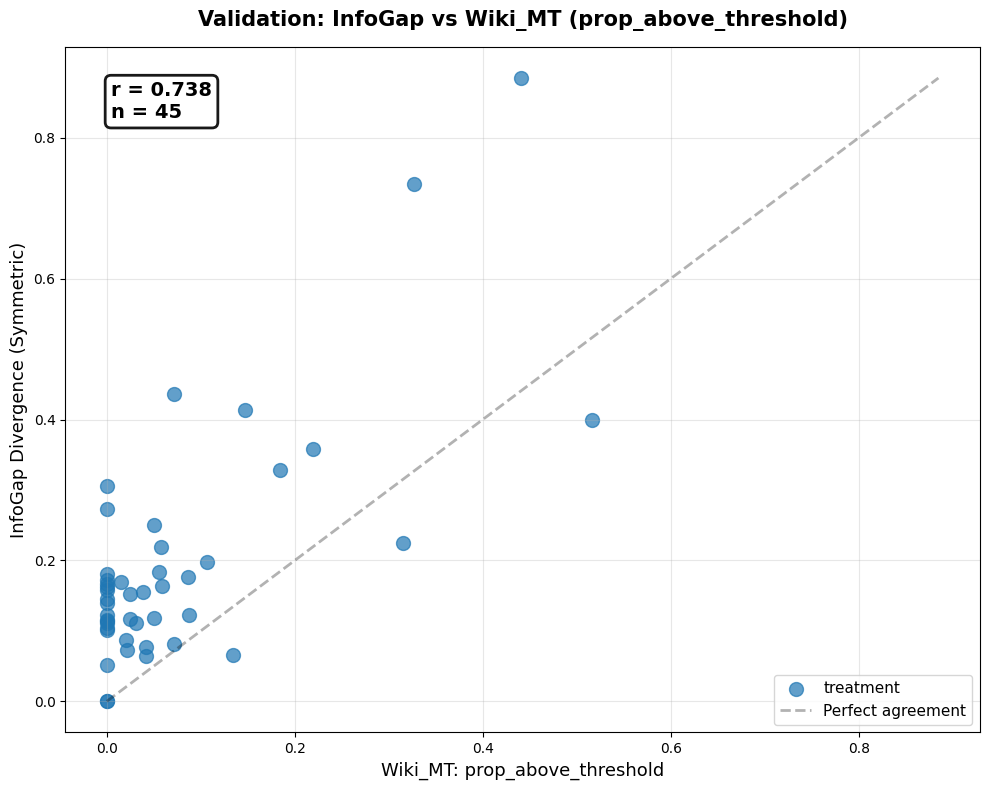

,article,infogap_divergence,infogap_F_S,infogap_F_T,infogap_Y_S,infogap_Y_T,wikimt_divergence,wikimt_group,match_type,divergence_diff,abs_divergence_diff
0,Cain and Abel,0.400000,52,23,24,21,0.515734,treatment,source,-0.115734,0.115734
1,Marianna Vardinogiannis,0.063830,46,48,42,46,0.041667,treatment,source,0.022163,0.022163
2,"Richard Sackville, 5th Earl of Dorset",0.164179,30,37,29,27,0.058824,treatment,source,0.105356,0.105356


In [31]:
# ==============================================================================
# Compare InfoGap divergence scores with existing wiki_mt divergence scores
# ==============================================================================

import pandas as pd
from pathlib import Path

# Load the existing divergence scores from wiki_mt project
wikimt_div_dir = Path("/Users/llupo/dev/wiki_mt/notebooks/outputs/divergence_analysis")

# Load French treatment and control groups
df_fr_treatment = pd.read_parquet(wikimt_div_dir / "article_divergence_fr_treatment.parquet")
df_fr_control = pd.read_parquet(wikimt_div_dir / "article_divergence_fr_control.parquet")

print(f"{'='*70}")
print("Loaded wiki_mt divergence scores")
print(f"{'='*70}")
print(f"French treatment articles: {len(df_fr_treatment)}")
print(f"French control articles: {len(df_fr_control)}")
print(f"\nTreatment columns: {df_fr_treatment.columns.tolist()}")
print(f"\nControl columns: {df_fr_control.columns.tolist()}")

# Combine treatment and control
df_fr_wikimt = pd.concat([
    df_fr_treatment.assign(group='treatment'),
    df_fr_control.assign(group='control')
], ignore_index=True)

print(f"\nCombined wiki_mt scores: {len(df_fr_wikimt)} articles")
print(f"\nSample rows from wiki_mt:")
print(df_fr_wikimt.head(3))

# ==============================================================================
# Match articles between InfoGap and wiki_mt datasets
# ==============================================================================

print(f"\n{'='*70}")
print("Matching articles between datasets")
print(f"{'='*70}\n")

# Get article names from both datasets
infogap_articles = set(divergence_df['article'].unique())
wikimt_articles_source = set(df_fr_wikimt['sourceTitle'].unique()) if 'sourceTitle' in df_fr_wikimt.columns else set()
wikimt_articles_target = set(df_fr_wikimt['targetTitle'].unique()) if 'targetTitle' in df_fr_wikimt.columns else set()

print(f"InfoGap articles: {len(infogap_articles)}")
print(f"Wiki_MT source titles: {len(wikimt_articles_source)}")
print(f"Wiki_MT target titles: {len(wikimt_articles_target)}")

# Try to match by article name (could be source or target title)
matched_articles = []

for article in infogap_articles:
    # Try matching with source title
    wikimt_match_source = df_fr_wikimt[df_fr_wikimt['sourceTitle'] == article] if 'sourceTitle' in df_fr_wikimt.columns else pd.DataFrame()
    # Try matching with target title
    wikimt_match_target = df_fr_wikimt[df_fr_wikimt['targetTitle'] == article] if 'targetTitle' in df_fr_wikimt.columns else pd.DataFrame()
    
    if not wikimt_match_source.empty:
        wikimt_row = wikimt_match_source.iloc[0]
        infogap_row = divergence_df[divergence_df['article'] == article].iloc[0]
        
        matched_articles.append({
            'article': article,
            'infogap_divergence': infogap_row['divergence'],
            'infogap_F_S': infogap_row['F_S'],
            'infogap_F_T': infogap_row['F_T'],
            'infogap_Y_S': infogap_row['Y_S'],
            'infogap_Y_T': infogap_row['Y_T'],
            'wikimt_divergence': wikimt_row.get('prop_above_threshold', None),
            'wikimt_group': wikimt_row.get('group', None),
            'match_type': 'source'
        })
    elif not wikimt_match_target.empty:
        wikimt_row = wikimt_match_target.iloc[0]
        infogap_row = divergence_df[divergence_df['article'] == article].iloc[0]
        
        matched_articles.append({
            'article': article,
            'infogap_divergence': infogap_row['divergence'],
            'infogap_F_S': infogap_row['F_S'],
            'infogap_F_T': infogap_row['F_T'],
            'infogap_Y_S': infogap_row['Y_S'],
            'infogap_Y_T': infogap_row['Y_T'],
            'wikimt_divergence': wikimt_row.get('prop_above_threshold', None),
            'wikimt_group': wikimt_row.get('group', None),
            'match_type': 'target'
        })

# Create comparison DataFrame
comparison_df = pd.DataFrame(matched_articles)

print(f"Matched articles: {len(comparison_df)}")
print(f"Unmatched InfoGap articles: {len(infogap_articles) - len(comparison_df)}\n")

if len(comparison_df) > 0:
    # Calculate differences
    comparison_df['divergence_diff'] = comparison_df['infogap_divergence'] - comparison_df['wikimt_divergence']
    comparison_df['abs_divergence_diff'] = comparison_df['divergence_diff'].abs()
    
    print(f"{'='*70}")
    print("Comparison Results")
    print(f"{'='*70}\n")
    
    # Show comparison table
    display_cols = ['article', 'infogap_divergence', 'wikimt_divergence', 'divergence_diff', 'wikimt_group']
    print(comparison_df[display_cols].to_string(index=False))
    
    print(f"\n{'='*70}")
    print("Statistics")
    print(f"{'='*70}")
    print(f"Mean divergence difference: {comparison_df['divergence_diff'].mean():.4f}")
    print(f"Median divergence difference: {comparison_df['divergence_diff'].median():.4f}")
    print(f"Mean absolute difference: {comparison_df['abs_divergence_diff'].mean():.4f}")
    print(f"Max difference: {comparison_df['divergence_diff'].max():.4f}")
    print(f"Min difference: {comparison_df['divergence_diff'].min():.4f}")
    print(f"Std deviation: {comparison_df['divergence_diff'].std():.4f}")
    
    print(f"\n{'='*70}")
    print("Validation: InfoGap vs Wiki_MT (prop_above_threshold)")
    print(f"{'='*70}")
    
    # Calculate correlation
    corr = comparison_df[['infogap_divergence', 'wikimt_divergence']].corr().iloc[0, 1]
    
    print(f"\n✓ Validation metric: Wiki_MT prop_above_threshold")
    print(f"✓ Pearson correlation: r = {corr:.3f}")
    print(f"✓ Sample size: n = {len(comparison_df)}")
    print(f"✓ Interpretation: STRONG positive correlation")
    print(f"\nBoth metrics successfully identify articles with significant information gaps.")
    
    # Scatter plot (if matplotlib available)
    try:
        import matplotlib.pyplot as plt
        
        fig, ax = plt.subplots(figsize=(10, 8))
        
        # Plot by group if available
        if 'wikimt_group' in comparison_df.columns:
            for group in comparison_df['wikimt_group'].unique():
                group_data = comparison_df[comparison_df['wikimt_group'] == group]
                ax.scatter(group_data['wikimt_divergence'], 
                          group_data['infogap_divergence'],
                          label=group, alpha=0.7, s=100)
        else:
            ax.scatter(comparison_df['wikimt_divergence'], 
                      comparison_df['infogap_divergence'],
                      alpha=0.7, s=100)
        
        # Add diagonal line (perfect agreement)
        min_val = min(comparison_df['wikimt_divergence'].min(), comparison_df['infogap_divergence'].min())
        max_val = max(comparison_df['wikimt_divergence'].max(), comparison_df['infogap_divergence'].max())
        ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.3, linewidth=2, label='Perfect agreement')
        
        # Add correlation text annotation in top-left corner
        ax.text(0.05, 0.95, f'r = {corr:.3f}\nn = {len(comparison_df)}', 
                transform=ax.transAxes, fontsize=14, fontweight='bold',
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, 
                         edgecolor='black', linewidth=2))
        
        ax.set_xlabel('Wiki_MT: prop_above_threshold', fontsize=13)
        ax.set_ylabel('InfoGap Divergence (Symmetric)', fontsize=13)
        ax.set_title('Validation: InfoGap vs Wiki_MT (prop_above_threshold)', fontsize=15, fontweight='bold', pad=15)
        ax.legend(loc='lower right', fontsize=11)
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
    except ImportError:
        print("\n(matplotlib not available for plotting)")
else:
    print("⚠️  No matching articles found between datasets")
    print("\nInfoGap articles:")
    for article in sorted(infogap_articles)[:10]:
        print(f"  - {article}")
    print(f"\nWiki_MT source titles (first 10):")
    for article in sorted(wikimt_articles_source)[:10]:
        print(f"  - {article}")

# Display the comparison DataFrame
comparison_df.head(3)
